In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
habits = pd.read_csv('/content/drive/MyDrive/DataFiles/habits.csv')
habits.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
habits.shape

(1000, 16)

In [10]:
habits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     909 non-null    object 
 1   age                            909 non-null    int64  
 2   gender                         909 non-null    object 
 3   study_hours_per_day            909 non-null    float64
 4   social_media_hours             909 non-null    float64
 5   netflix_hours                  909 non-null    float64
 6   part_time_job                  909 non-null    object 
 7   attendance_percentage          909 non-null    float64
 8   sleep_hours                    909 non-null    float64
 9   diet_quality                   909 non-null    object 
 10  exercise_frequency             909 non-null    int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               909 non-null    object 


In [6]:
habits.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [7]:
habits.dropna(inplace=True, axis=0)
habits.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [8]:
habits.duplicated().sum()

np.int64(0)

In [13]:
categorical_col = habits.select_dtypes(include='object').columns
categorical_col = categorical_col.drop('student_id')
categorical_col

Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object')

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
habits_enc = habits.copy()
habits_enc[categorical_col] = habits_enc[categorical_col].apply(le.fit_transform)
habits_enc.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,S1001,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,S1002,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,S1003,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,S1004,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
habits_enc_scaled= scaler.fit_transform(habits_enc.drop(columns='student_id'))
habits_enc_scaled = pd.DataFrame(habits_enc_scaled, columns=habits_enc.drop(columns='student_id').columns)
habits_enc_scaled.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,1.097025,-0.987703,-2.409063,-1.120653,-0.682160,-0.524304,0.118506,1.252562,-1.003360,1.449141,1.652907,-1.097370,0.887113,1.464694,-0.789486
1,-0.206499,-0.987703,2.288261,0.253727,0.438642,-0.524304,1.420311,-1.538274,0.339872,1.449141,0.276998,-1.097370,0.887113,-0.682736,1.799148
2,0.228009,0.765856,-1.455982,0.511424,-0.495360,-0.524304,1.155716,1.252562,1.683104,-1.008451,0.276998,1.736463,-1.563908,-0.682736,-2.083803
3,1.097025,-0.987703,-1.728291,1.198614,-0.775560,-0.524304,-1.363223,2.237564,1.683104,0.466104,1.652907,0.319547,-1.563908,1.464694,-2.527062
4,-0.641007,-0.987703,0.994795,1.628108,-1.242561,-0.524304,0.742949,-1.292024,-1.003360,-0.025414,1.652907,0.319547,-1.563908,-0.682736,-0.186653


In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
habits_pca = pca.fit_transform(habits_enc_scaled)
habits_pca = pd.DataFrame(habits_pca, columns=['PC1', 'PC2'])
habits_pca.head()

,PC1,PC2
0,-1.292453,-0.792266
1,3.014228,0.586380
2,-2.846425,-1.844139
3,-3.329774,-1.154624
4,0.055897,1.104609


##Using KMeans

Silhouette Score for 2 clusters: 0.35245134855543303
Silhouette Score for 3 clusters: 0.3268877264901025
Silhouette Score for 4 clusters: 0.35533423865943725
Silhouette Score for 5 clusters: 0.3367621231583972
Silhouette Score for 6 clusters: 0.32174458584066473
Silhouette Score for 7 clusters: 0.3192704700576358
Silhouette Score for 8 clusters: 0.31853154881089035
Silhouette Score for 9 clusters: 0.29981923998955884


Text(0, 0.5, 'WCSS')

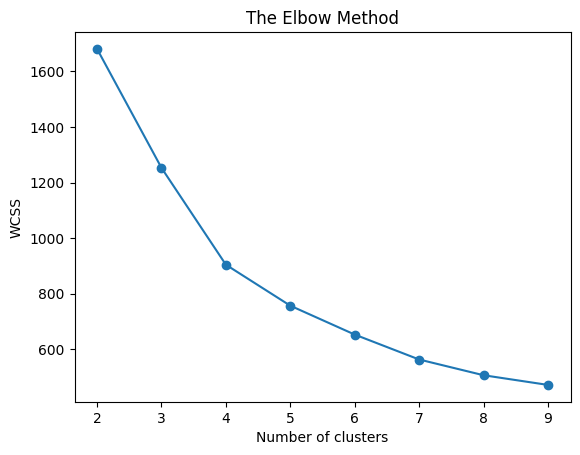

In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
for i in range(2, 10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(habits_pca)
  wcss.append(kmeans.inertia_)
  print(f'Silhouette Score for {i} clusters: {silhouette_score(habits_pca, kmeans.labels_)}')

plt.plot(range(2, 10), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [97]:
kmeans = KMeans(n_clusters=4, random_state=42)
habits_pca['cluster'] = kmeans.fit_predict(habits_pca)
habits_pca.head()

,PC1,PC2,cluster
0,-1.292453,-0.792266,3
1,3.014228,0.586380,2
2,-2.846425,-1.844139,3
3,-3.329774,-1.154624,3
4,0.055897,1.104609,0


In [98]:
import plotly.express as px

fig = px.scatter(habits_pca, x='PC1', y='PC2', color='cluster',
                    title='Clustering')
fig.show()

### Clustering clearly shows 4 proper clusters

In [99]:
habits['Cluster'] = habits_pca['cluster']
habits.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,Cluster,Cluster_Label
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,3.0,Media-Engaged Achievers
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2.0,Healthy But Underperforming
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,3.0,Media-Engaged Achievers
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,3.0,Media-Engaged Achievers
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,0.0,Stable Performers


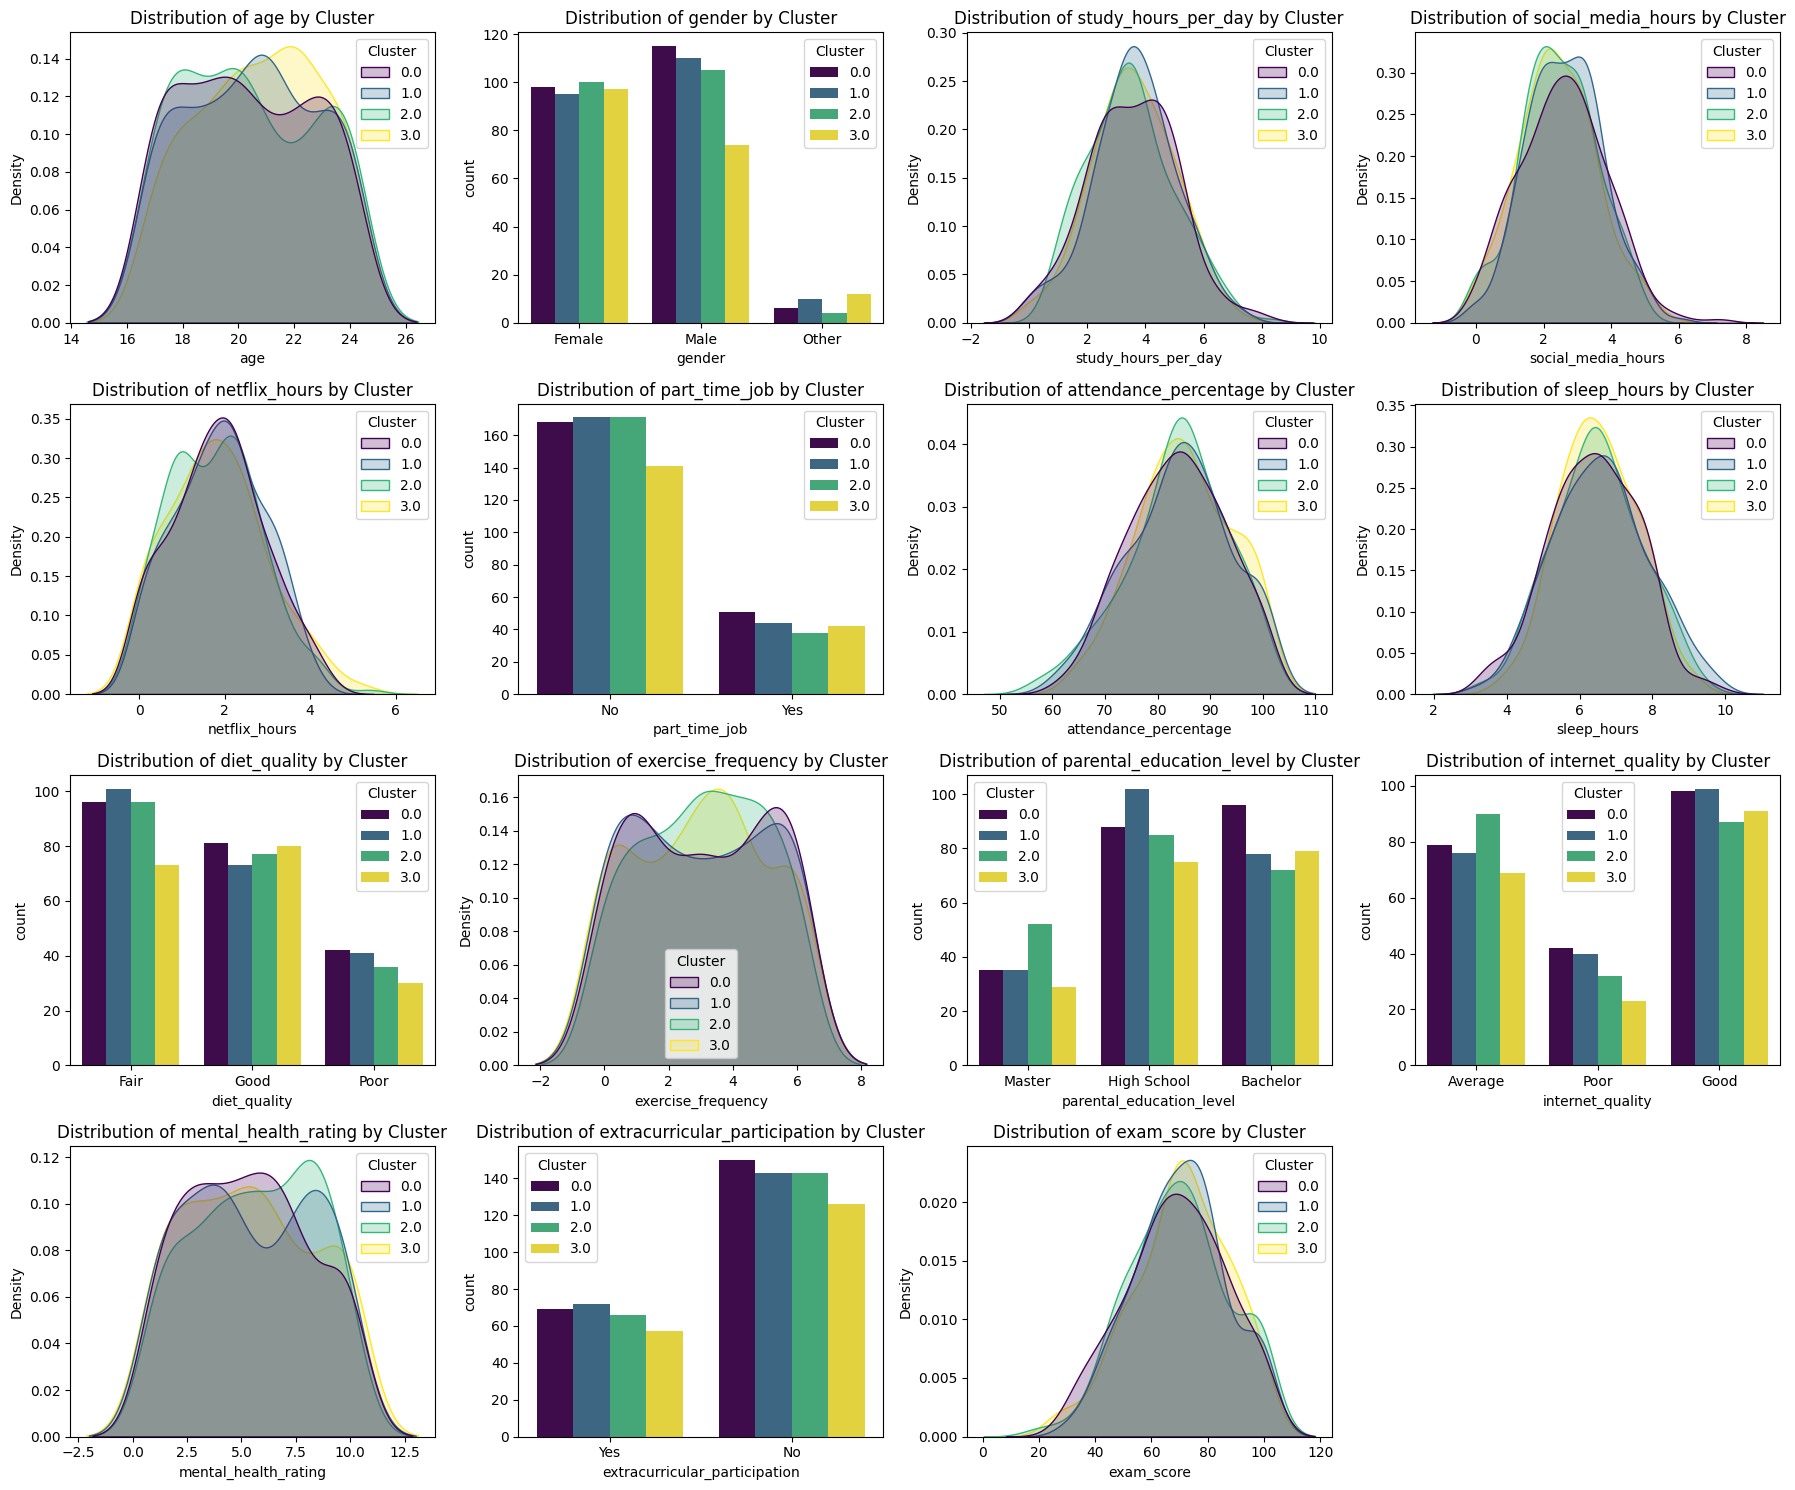

In [100]:
plt.figure(figsize=(18, 15))
num_rows = int(np.ceil(len(features) / 4))
for i, col in enumerate(features):
    plt.subplot(num_rows, 4, i + 1)
    if habits[col].dtype in ['int64', 'float64']:  # Check if column is numeric
        sbn.kdeplot(data=habits, x=col, hue='Cluster', fill=True, common_norm=False, palette='viridis')
    else:
        sbn.countplot(data=habits, x=col, hue='Cluster', palette='viridis')  # Use countplot for categorical data
    plt.title(f'Distribution of {col} by Cluster')

plt.tight_layout()
plt.show()


## 🧠 Updated Cluster Analysis (Based on `exam_score` Statistics)

### 🟩 Stable Performers
- **Score Mean**: 68.78 (slightly below overall average).
- **Profile**: Appear average in performance, may lack extremes in habits.
- **Label Justification**: Likely have stable routines but not excelling.

---

### 🟥 Meda-Engaged Achievers
- **Score Mean**: 70.49 (second highest).
- **Profile**: Despite potentially higher media usage, they perform well.
- **Label Justification**: Possibly motivated multitaskers

---

### 🟦 Healthy but Underperforming
- **Score Mean**: 68.60 (**lowest** of all).
- **Profile**: The label contradicts the score data.
- **Label Justification**: This cluster may have good habits (e.g., study/sleep/exercise), but it doesn't reflect in scores.

---

### 🟨 Efficient Workers
- **Score Mean**: **70.94** (**highest** of all).
- **Profile**: Balancing part-time work and studies, yet scoring the highest.
- **Label Justification**: Very effective time managers.

---


In [87]:
cluster_labels = {
    0: "Stable Performers",
    1: "Media-Engaged Achievers",
    2: "Healthy But Underperforming",
    3: "Efficient Workers"
}

habits['Cluster_Label'] = habits['Cluster'].map(cluster_labels)

In [101]:
by_cluster_score = habits.groupby('Cluster_Label')['exam_score'].describe()
by_cluster_score

,count,mean,std,min,25%,50%,75%,max
Cluster_Label,,,,,,,,
Efficient Workers,248.0,70.943548,16.162213,29.7,60.275,70.9,81.15,100.0
Healthy But Underperforming,175.0,68.597714,17.731241,18.4,56.600,68.7,80.55,100.0
Media-Engaged Achievers,183.0,70.490710,16.952979,26.7,60.900,70.9,83.25,100.0
Stable Performers,220.0,68.779091,17.632722,26.2,57.225,69.0,81.10,100.0


In [102]:
by_cluster_attend = habits.groupby('Cluster_Label')['attendance_percentage'].describe()
by_cluster_attend

,count,mean,std,min,25%,50%,75%,max
Cluster_Label,,,,,,,,
Efficient Workers,248.0,83.837097,9.672478,59.5,77.375,84.0,90.625,100.0
Healthy But Underperforming,175.0,83.996571,9.440442,56.7,78.800,85.1,90.150,100.0
Media-Engaged Achievers,183.0,85.079235,8.967702,64.0,79.050,84.8,92.100,100.0
Stable Performers,220.0,83.668182,9.167338,60.6,77.275,83.9,90.700,100.0


In [103]:
habits['media_hours'] = habits['netflix_hours'] + habits['social_media_hours']
by_cluster_media = habits.groupby('Cluster_Label')['media_hours'].describe()
by_cluster_media

,count,mean,std,min,25%,50%,75%,max
Cluster_Label,,,,,,,,
Efficient Workers,248.0,4.425000,1.492037,0.6,3.500,4.4,5.50,8.2
Healthy But Underperforming,175.0,4.249714,1.595283,0.7,3.150,4.4,5.30,8.7
Media-Engaged Achievers,183.0,4.245902,1.633970,0.2,3.100,4.4,5.15,9.2
Stable Performers,220.0,4.421818,1.703040,0.4,3.275,4.5,5.60,10.1


In [104]:
by_cluster_study = habits.groupby('Cluster_Label')['study_hours_per_day'].describe()
by_cluster_study

,count,mean,std,min,25%,50%,75%,max
Cluster_Label,,,,,,,,
Efficient Workers,248.0,3.667339,1.425314,0.0,2.775,3.6,4.525,7.4
Healthy But Underperforming,175.0,3.394857,1.521126,0.5,2.250,3.4,4.300,8.3
Media-Engaged Achievers,183.0,3.572131,1.438268,0.0,2.600,3.5,4.550,7.4
Stable Performers,220.0,3.548182,1.539568,0.0,2.500,3.5,4.600,8.2
